# Object Detection vs Panoptic Segmentation in Adverse Weather Conditions

This is the main environment of the project comparing object detection and panoptic segmentation models under challenging weather conditions.

In [2]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
import sys
from ultralytics import YOLO
from PIL import Image

the device chosen and train the models is a rtx 4060M with 8gb VRAM

the dataset so far is ACDC.
other options:
WEDGE, DAWN, Cityscapes, COCO.

In [3]:
data_path = 'C:\\desktop 2\\project\\datasets\\ACDC'
models_path = 'C:\\desktop 2\\project\\models'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Data orginizations, so far 70% training 20% validation and 10% test.

resolution hasn't been decided yet and the full data extraction isnt been implemented yet

In [ ]:
import glob
def dataFromPath(dataPath):
  path = data_path + dataPath
  images = {}
  for file in glob.glob(path):
      filename = file.split("\\")[-1]            # get the name of the .jpg file
      img = np.asarray(Image.open(file))        # read the image as a numpy array
      img =  np.array(img)/255 - 0.5
      images[filename] = img[:, :, :3]          # remove the alpha channel

  database = []

  # Populate train_data array
  for  (file_name, image) in images.items():
      id, pair_number, shoe_side, sex = file_name.split('_')
      person_index = int(id[1:]) - 1
      if shoe_side == 'left':
        shoe_side_index = 0
      else:
        shoe_side_index = 1
      pair_index = int(pair_number) - 1
      database.append([person_index,[pair_index, shoe_side_index],np.array(image)])

  database = sorted(database,key=lambda x: x[0])

  person_num = len(images)/6

  fin_data = np.zeros((int(person_num),3,2,224,224,3))
  for i,obj in enumerate(database):
    fin_data[i//6,obj[1][0],obj[1][1]] = obj[2]

  return fin_data

train_data = dataFromPath("data/train/*.jpg")
valid_data = train_data[90:]
train_data = train_data[:90]
test_data = dataFromPath("data/validation/*.jpg")

print("Shape of: Train - ", train_data.shape, "Validation - ", valid_data.shape)

NameError: name 'data_path' is not defined

models loading

In [3]:
#Panoptic_segmentation_model = torch.hub.load(models_path, 'mask2former_r50_lsj_8x2_50e_coco_20220506_191028-8e96e88b.pth', pretrained=True)
#object_detection_model = torch.hub.load(models_path, 'yolov12l.pt', pretrained=True)
model = YOLO(r"c:\\desktop 2\\project\\models\\yolov12l.pt")

Training, this training function works with ADAM.
Reduce LT on Plateau scheduler
gradiant clipping
and checkpoints

In [ ]:
# you can change the signature and structure of this function as you please
# the code and comments below are only a suggestion to get you started
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_model(
    model,
    train_data,
    validation_data,
    batch_size=20,
    learning_rate=0.001,
    weight_decay=1e-3,
    epochs=30,
    checkpoint_path=None
):
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5, verbose=True)
    
    best_valid_loss = float('inf')
    best_valid_acc = 0
    loss_data = []
    
    print(f"Training for Model {model.__class__.__name__}")
    print(f"n: {model.n}, Learning Rate: {learning_rate}, Weight Decay: {weight_decay}, "
          f"Epochs: {epochs}, Batch Size: {batch_size}")
    
    for epoch in range(epochs):
        model.train()
        
        positive_pair = generate_same_pair(train_data)
        negative_pair = generate_different_pair(train_data)
        
        reindex = np.random.permutation(len(negative_pair))
        negative_pair = negative_pair[reindex]
        reindex = np.random.permutation(len(positive_pair))
        positive_pair = positive_pair[reindex]
        
        for i in range(0, len(positive_pair), batch_size // 2):
            print(f"\r{epoch} {int(100 * i / len(positive_pair))}%", end='')
            
            pos_batch = positive_pair[i:i + batch_size // 2]
            neg_batch = negative_pair[i:i + batch_size // 2]
            
            if len(pos_batch) < batch_size // 2:
                continue
            
            batch = np.concatenate([pos_batch, neg_batch], axis=0)
            labels = np.concatenate([np.ones(len(pos_batch)), np.zeros(len(neg_batch))])
            
            reindex = np.random.permutation(len(batch))
            batch = batch[reindex]
            labels = labels[reindex]
            
            data = torch.Tensor(batch).permute(0, 3, 1, 2).to(device)
            labels = torch.Tensor(labels).long().to(device)
            
            # Training step
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, labels)
            loss.backward()
            
            # gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.5)
            
            optimizer.step()
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_positive_pair = generate_same_pair(validation_data)
            val_negative_pair = generate_different_pair(validation_data)
            
            val_inputs = np.concatenate([val_positive_pair, val_negative_pair], axis=0)
            val_inputs = torch.Tensor(val_inputs).permute(0, 3, 1, 2).to(device)
            num_val = len(val_positive_pair)
            val_labels = np.concatenate([np.ones(num_val), np.zeros(num_val)])
            val_labels = torch.Tensor(val_labels).long().to(device)
            
            pos_valid_accuracy, neg_valid_accuracy = get_accuracy(model, validation_data, batch_size=15, device=device)
            pos_train_accuracy, neg_train_accuracy = get_accuracy(model, train_data, batch_size=15, device=device)
            
            valid_loss = criterion(model(val_inputs), val_labels).item()
            valid_acc = 100 * (0.5 * (pos_valid_accuracy + neg_valid_accuracy))
            train_accuracy = 100 * (0.5 * (pos_train_accuracy + neg_train_accuracy))
            
            loss_data.append([epoch, valid_loss, loss.item()])
            
            print(
                f'\rEpoch [{epoch + 1}/{epochs}], '
                f'Val Loss: {valid_loss:.6f}, '
                f'Train Acc: {train_accuracy:.2f}, '
                f'Pos Val Acc: {pos_valid_accuracy*100:.2f}, '
                f'Neg Val Acc: {neg_valid_accuracy*100:.2f}, '
                f'Val Acc: {valid_acc:.2f}, '
                f'LR: {optimizer.param_groups[0]["lr"]:.8f}'
            )
            
            # Checkpoint
            if best_valid_acc == valid_acc and valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
                name = model.__class__.__name__
                if checkpoint_path:
                    torch.save(model.state_dict(), 
                             f"{checkpoint_path}\\training_best_{name}.pk")
            
            if best_valid_acc < valid_acc:
                best_valid_acc = valid_acc
                best_valid_loss = valid_loss
                name = model.__class__.__name__
                if checkpoint_path:
                    torch.save(model.state_dict(), 
                             f"{checkpoint_path}\\training_best_{name}.pk")
            
            # Update learning rate
            scheduler.step(valid_loss)
    
    print(f'\nBest validation loss: {best_valid_loss:.6f}, '
          f'Best validation accuracy: {best_valid_acc:.2f}')
    
    model.load_state_dict(torch.load(f"{checkpoint_path}\\training_best_{name}.pk"))
    
    return best_valid_loss, best_valid_acc


evaluation so far will be PQ mAQ@50 and F1 for the models


image 1/11 C:\desktop 2\project\datasets\ACDC\cloudy_0.jpg: 640x640 3 persons, 1 backpack, 26.9ms
image 1/11 C:\desktop 2\project\datasets\ACDC\cloudy_0.jpg: 640x640 3 persons, 1 backpack, 26.9ms
image 2/11 C:\desktop 2\project\datasets\ACDC\cloudy_1.jpg: 640x640 5 persons, 26.7ms
image 2/11 C:\desktop 2\project\datasets\ACDC\cloudy_1.jpg: 640x640 5 persons, 26.7ms
image 3/11 C:\desktop 2\project\datasets\ACDC\cloudy_10.jpg: 640x640 3 persons, 1 handbag, 26.8ms
image 3/11 C:\desktop 2\project\datasets\ACDC\cloudy_10.jpg: 640x640 3 persons, 1 handbag, 26.8ms
image 4/11 C:\desktop 2\project\datasets\ACDC\cloudy_2.jpg: 640x640 3 persons, 26.6ms
image 4/11 C:\desktop 2\project\datasets\ACDC\cloudy_2.jpg: 640x640 3 persons, 26.6ms
image 5/11 C:\desktop 2\project\datasets\ACDC\cloudy_3.jpg: 640x640 4 persons, 1 train, 26.7ms
image 5/11 C:\desktop 2\project\datasets\ACDC\cloudy_3.jpg: 640x640 4 persons, 1 train, 26.7ms
image 6/11 C:\desktop 2\project\datasets\ACDC\cloudy_4.jpg: 640x640 1 tra

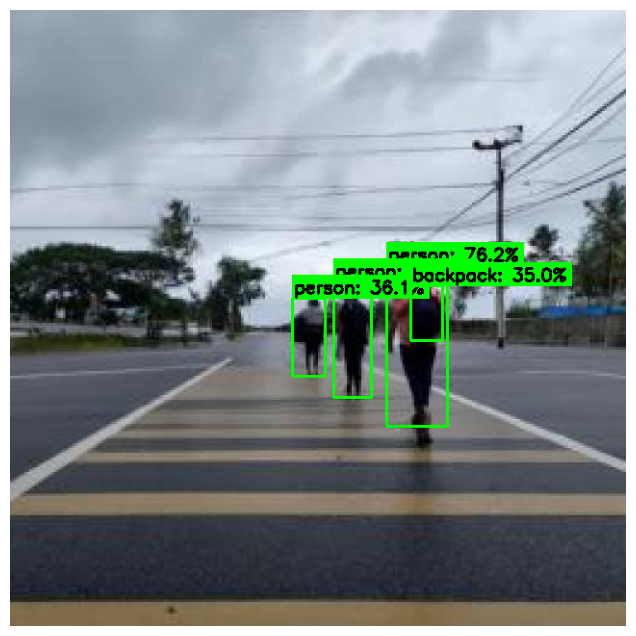

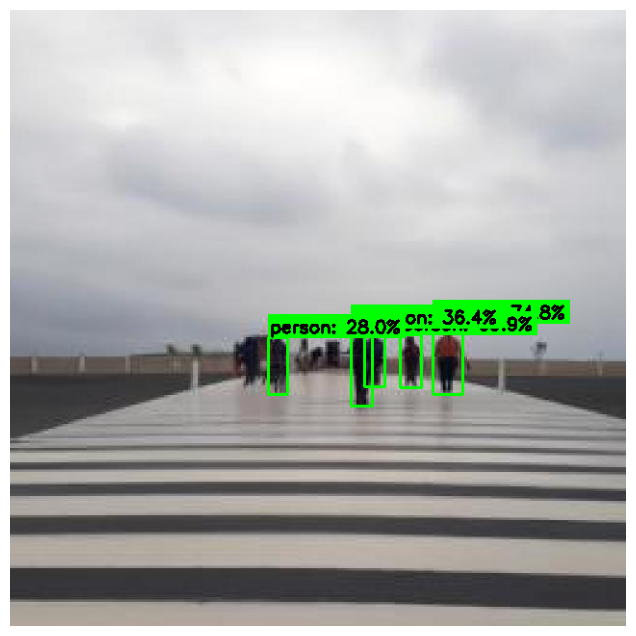

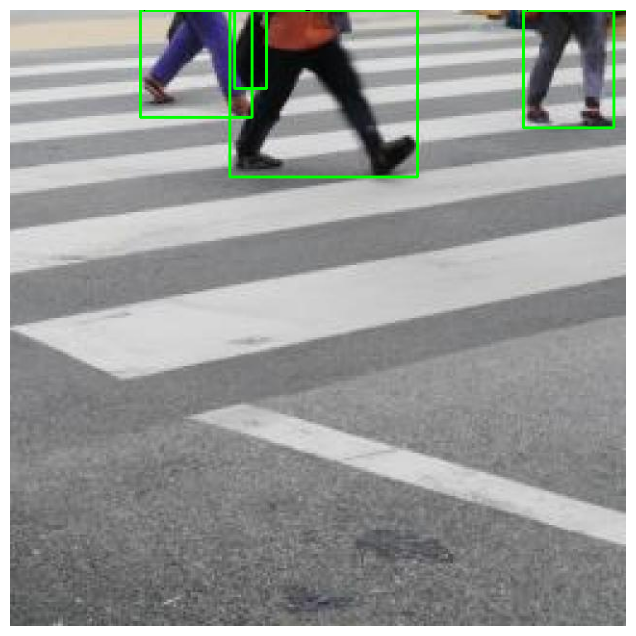

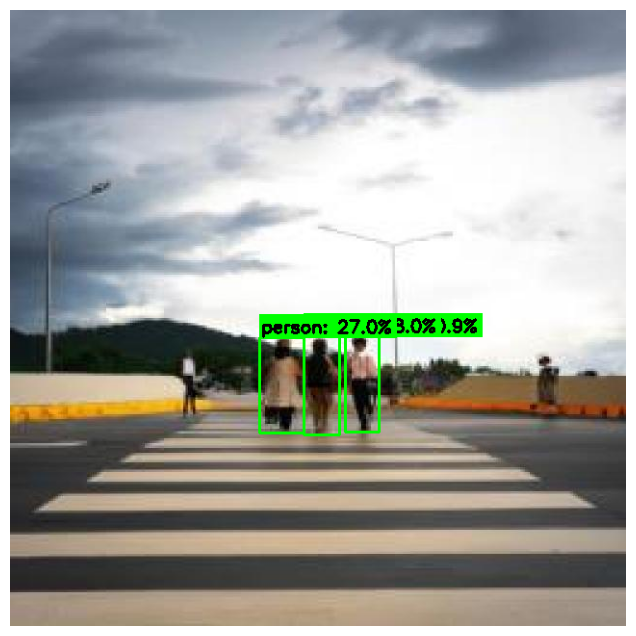

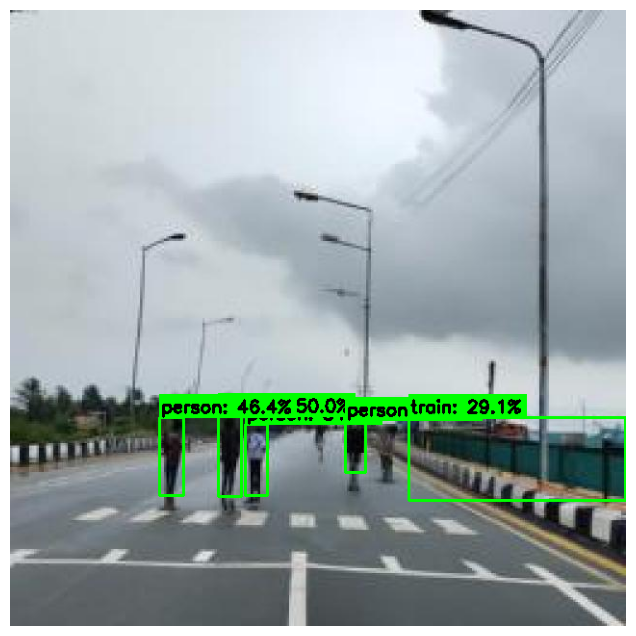

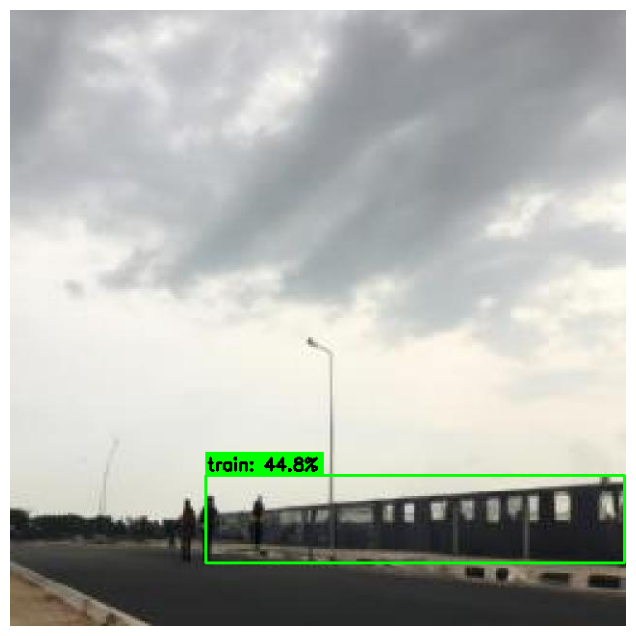

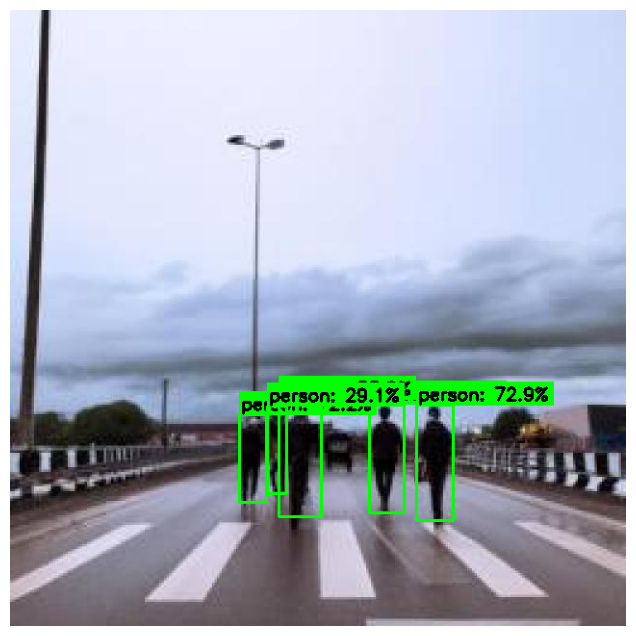

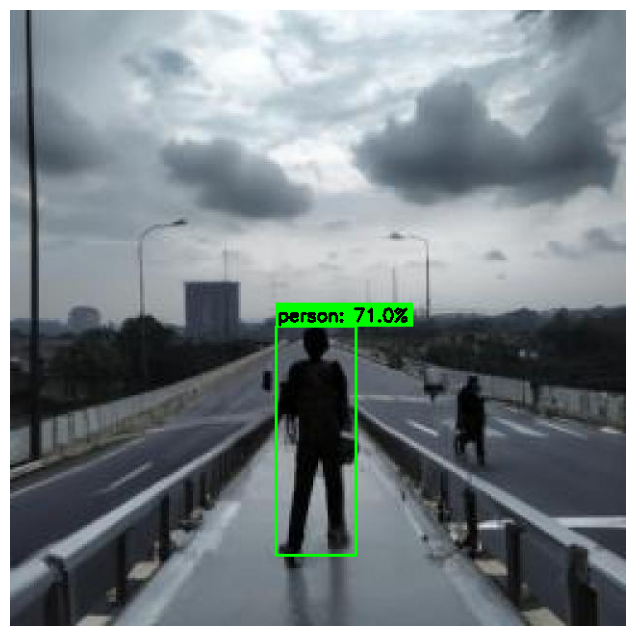

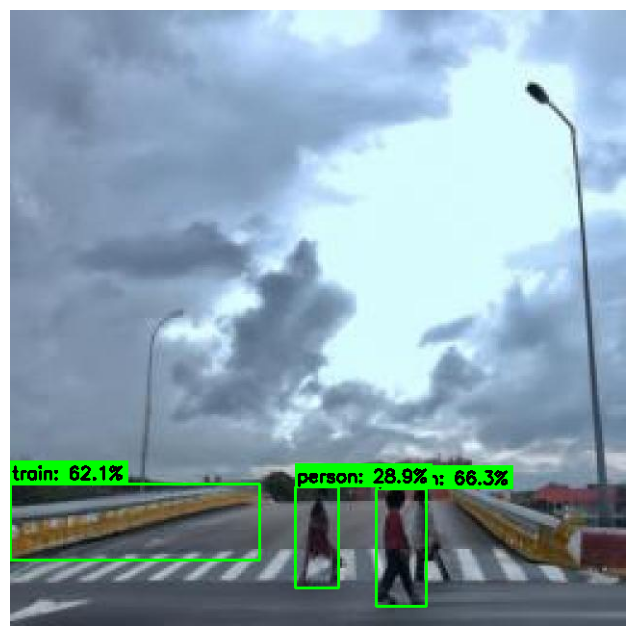

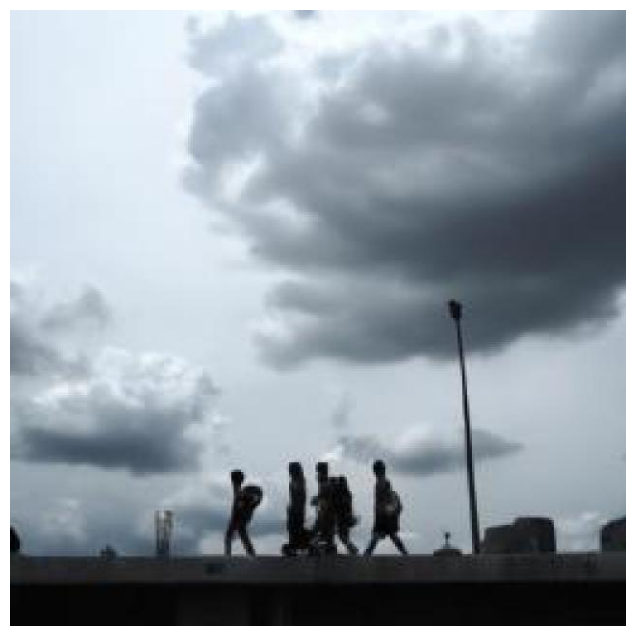

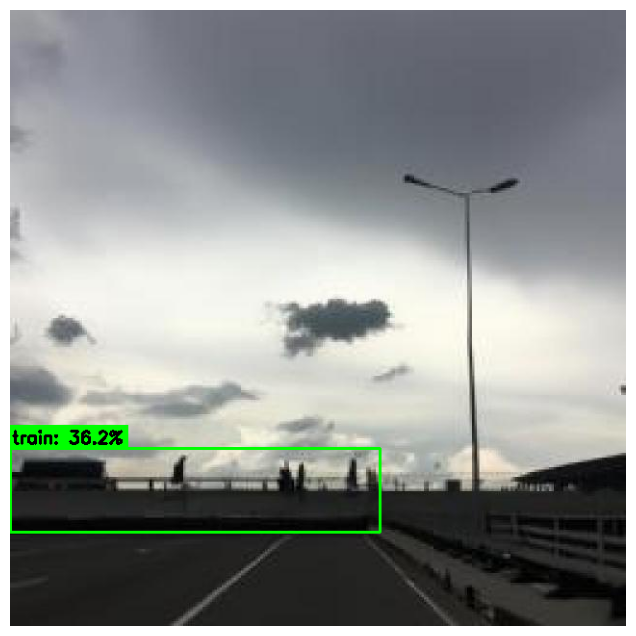

In [4]:
results = model.predict(
    source=str(data_path),  # accepts single file, folder, glob, webcam, etc.
    imgsz=640,              # forces 640×640 inference
    conf=0.25,              # tweak as desired
    save=True               # saves annotated images in runs/detect/predict
)

# Display results with bounding boxes and confidence percentages
for r in results:
    # Get the original image
    img = r.orig_img.copy()
    
    # Draw bounding boxes and labels with confidence
    if r.boxes is not None and len(r.boxes) > 0:
        for box in r.boxes:
            # Get box coordinates
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            
            # Get confidence and class
            conf = box.conf[0].cpu().numpy() * 100  # Convert to percentage
            cls_id = int(box.cls[0].cpu().numpy())
            cls_name = r.names[cls_id]
            
            # Draw rectangle (bounding box)
            color = (0, 255, 0)  # Green color
            thickness = 2
            img = cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
            
            # Create label with class name and confidence percentage
            label = f"{cls_name}: {conf:.1f}%"
            
            # Calculate text size for background rectangle
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.6
            font_thickness = 2
            (text_width, text_height), baseline = cv2.getTextSize(label, font, font_scale, font_thickness)
            
            # Draw background rectangle for text
            cv2.rectangle(img, (x1, y1 - text_height - 10), (x1 + text_width + 5, y1), color, -1)
            
            # Draw text
            cv2.putText(img, label, (x1 + 2, y1 - 5), font, font_scale, (0, 0, 0), font_thickness)
    
    # Convert BGR to RGB for display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Display the image
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

## Mask2Former-R50 Panoptic Segmentation

In [4]:
# Mask2Former-R50 using Hugging Face Transformers (easier to install than MMDetection)
# pip install transformers

import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Try Hugging Face Transformers approach (easier on Windows)
try:
    from transformers import Mask2FormerForUniversalSegmentation, Mask2FormerImageProcessor
    
    # Load pre-trained Mask2Former model from Hugging Face
    processor = Mask2FormerImageProcessor.from_pretrained("facebook/mask2former-swin-base-coco-panoptic")
    mask2former_model = Mask2FormerForUniversalSegmentation.from_pretrained("facebook/mask2former-swin-base-coco-panoptic")
    mask2former_model.to(device)
    mask2former_model.eval()
    
    print("Mask2Former model loaded successfully using Hugging Face Transformers!")
    print(f"Running on: {device}")
    USE_HF = True
    
except ImportError as e:
    print(f"Transformers not available: {e}")
    print("Please install: pip install transformers")
    USE_HF = False

# Also try loading local weights for reference
local_pth = r"C:\desktop 2\project\models\mask2former_r50_lsj_8x2_50e_coco_20220506_191028-8e96e88b.pth"
local_safetensors = r"C:\desktop 2\project\models\mask2former-R50.safetensors"

if os.path.exists(local_pth):
    print(f"\nLocal model available: {local_pth}")
if os.path.exists(local_safetensors):
    print(f"Local safetensors available: {local_safetensors}")

c:\desktop 2\project\venv310\lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `Mask2FormerImageProcessor.__init__` and were ignored: '_max_size', 'reduce_labels'
  image_processor = cls(**image_processor_dict)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Mask2Former model loaded successfully using Hugging Face Transformers!
Running on: cuda

Local model available: C:\desktop 2\project\models\mask2former_r50_lsj_8x2_50e_coco_20220506_191028-8e96e88b.pth
Local safetensors available: C:\desktop 2\project\models\mask2former-R50.safetensors


Found 11 images in ACDC dataset

Processing: cloudy_0.jpg


`label_ids_to_fuse` unset. No instance will be fused.


  [Stuff] sky: 100.0%
  [Stuff] road: 99.1%
  [Thing] person: 99.4%
  [Stuff] tree: 99.7%
  [Stuff] fence: 92.0%
  [Thing] person: 100.0%
  [Thing] person: 99.9%


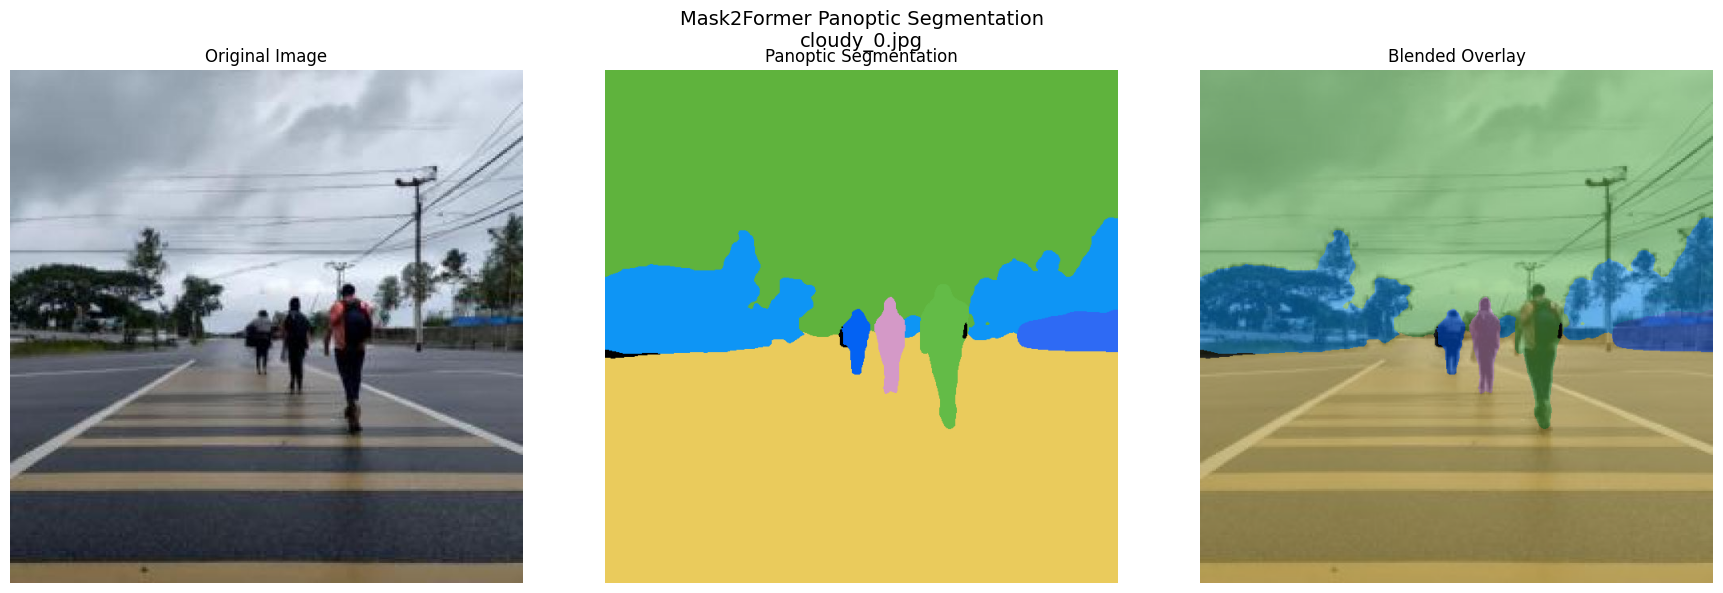

`label_ids_to_fuse` unset. No instance will be fused.


Total segments detected: 7

Processing: cloudy_1.jpg
  [Stuff] sky: 99.9%
  [Thing] person: 98.7%
  [Thing] person: 93.3%
  [Thing] person: 82.7%
  [Thing] person: 99.7%
  [Thing] person: 99.1%
  [Thing] person: 99.7%
  [Thing] person: 99.9%
  [Thing] person: 96.3%
  [Stuff] pavement: 90.8%


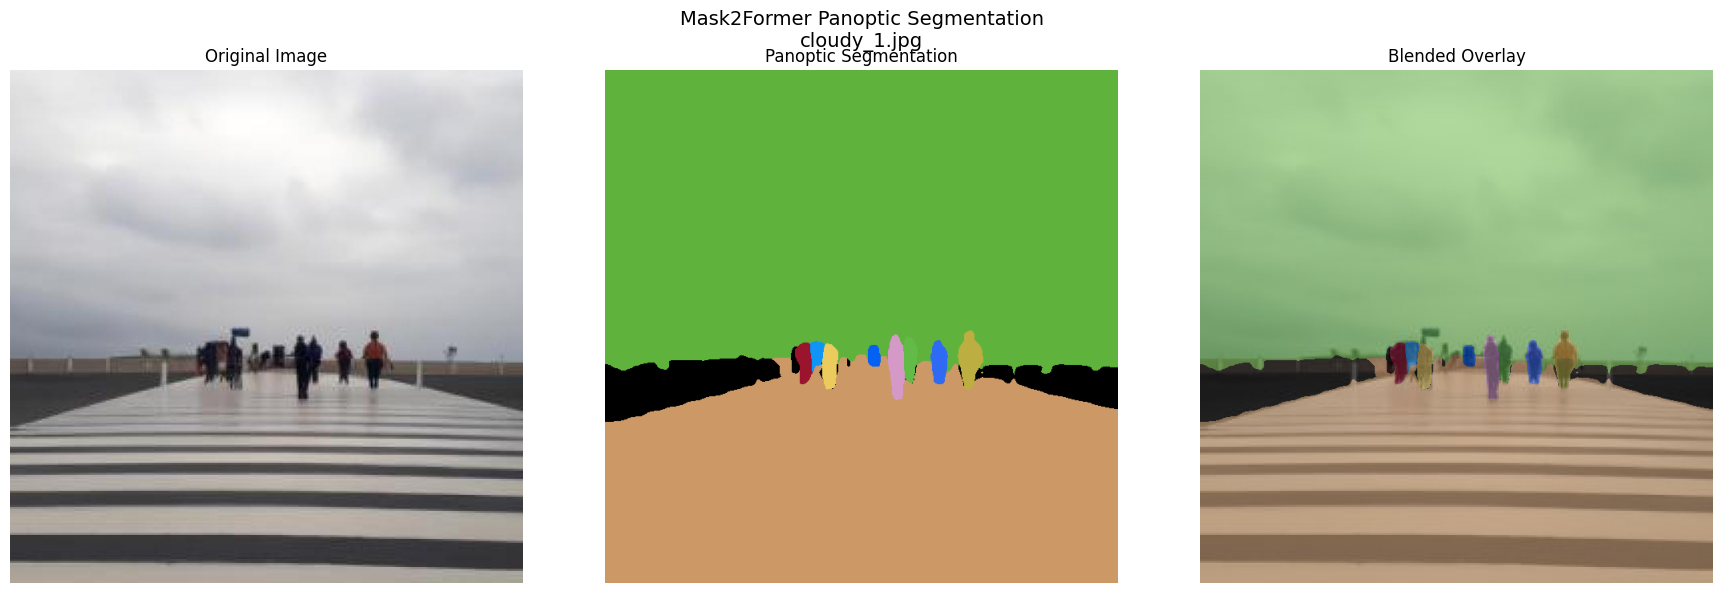

`label_ids_to_fuse` unset. No instance will be fused.


Total segments detected: 10

Processing: cloudy_10.jpg
  [Stuff] road: 99.4%
  [Thing] handbag: 79.2%
  [Thing] person: 99.9%
  [Thing] handbag: 66.4%
  [Thing] person: 100.0%
  [Thing] person: 100.0%


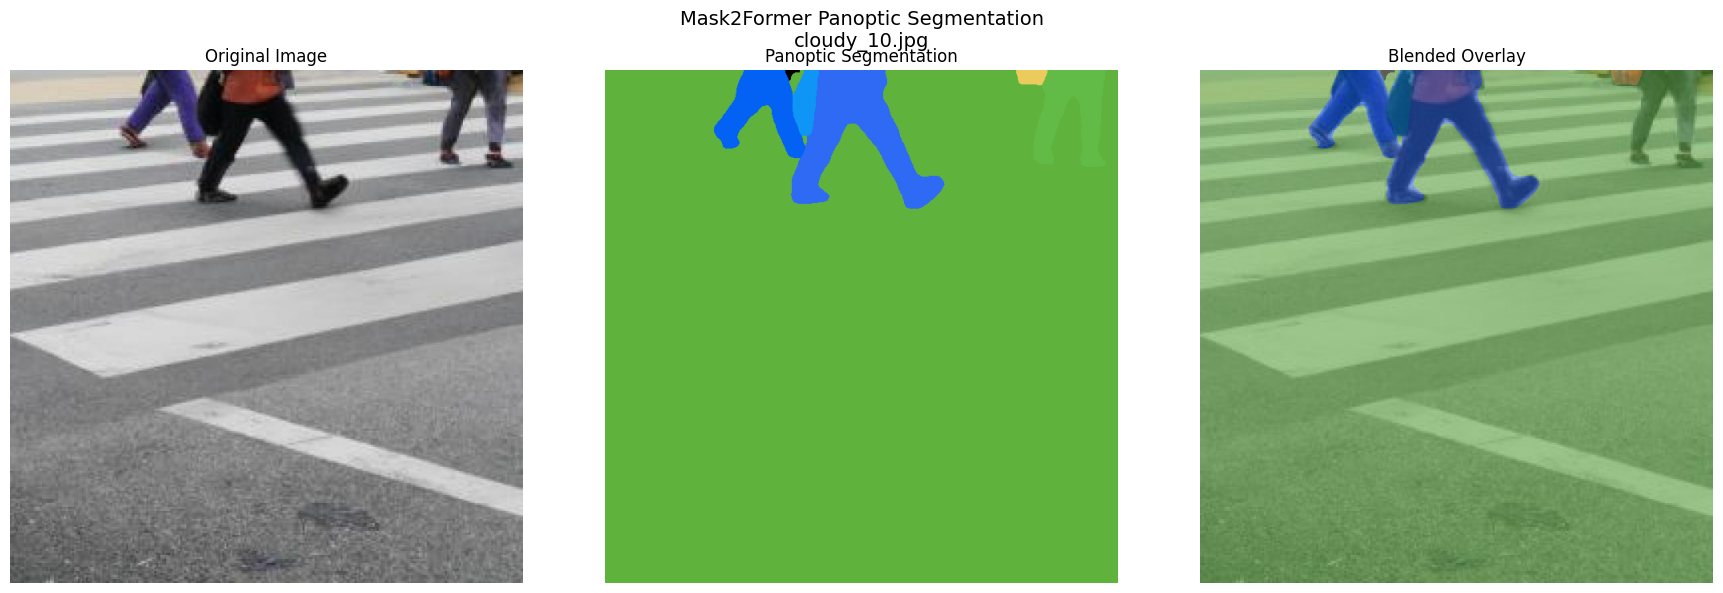

`label_ids_to_fuse` unset. No instance will be fused.


Total segments detected: 6

Processing: cloudy_2.jpg
  [Stuff] sky: 100.0%
  [Stuff] road: 97.6%
  [Thing] person: 100.0%
  [Thing] person: 98.9%
  [Thing] person: 99.9%
  [Thing] person: 98.0%
  [Thing] person: 100.0%
  [Stuff] mountain: 98.6%
  [Stuff] wall: 88.1%
  [Thing] person: 67.1%


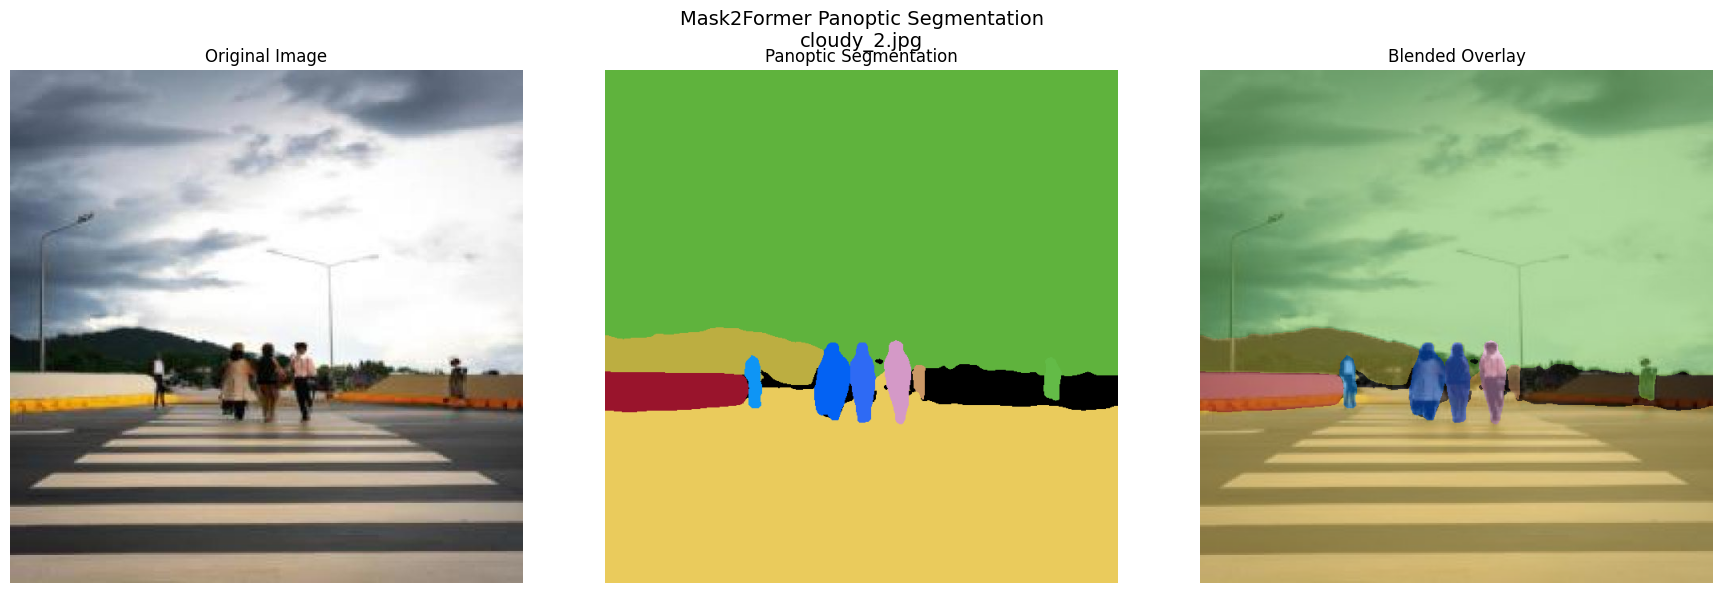

`label_ids_to_fuse` unset. No instance will be fused.


Total segments detected: 10

Processing: cloudy_3.jpg
  [Stuff] sky: 99.9%
  [Stuff] road: 99.0%
  [Thing] person: 99.7%
  [Stuff] tree: 98.5%
  [Thing] person: 99.0%
  [Thing] person: 98.5%
  [Thing] person: 99.8%
  [Thing] person: 99.5%
  [Stuff] wall: 68.5%
  [Thing] person: 99.8%


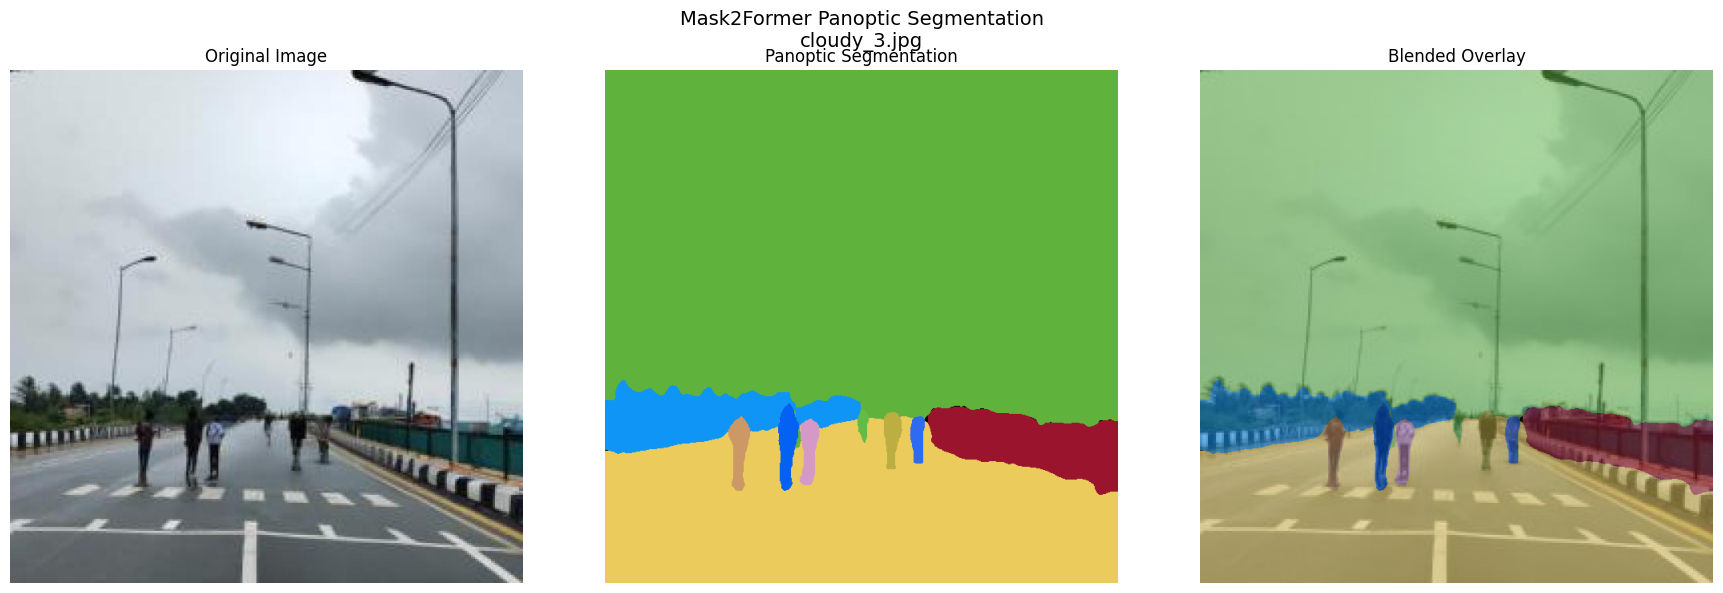

`label_ids_to_fuse` unset. No instance will be fused.


Total segments detected: 10

Processing: cloudy_4.jpg
  [Stuff] sky: 100.0%
  [Stuff] road: 96.2%
  [Thing] person: 99.0%
  [Stuff] pavement: 86.0%
  [Thing] train: 88.9%
  [Thing] person: 98.7%
  [Thing] person: 99.8%
  [Thing] person: 51.8%


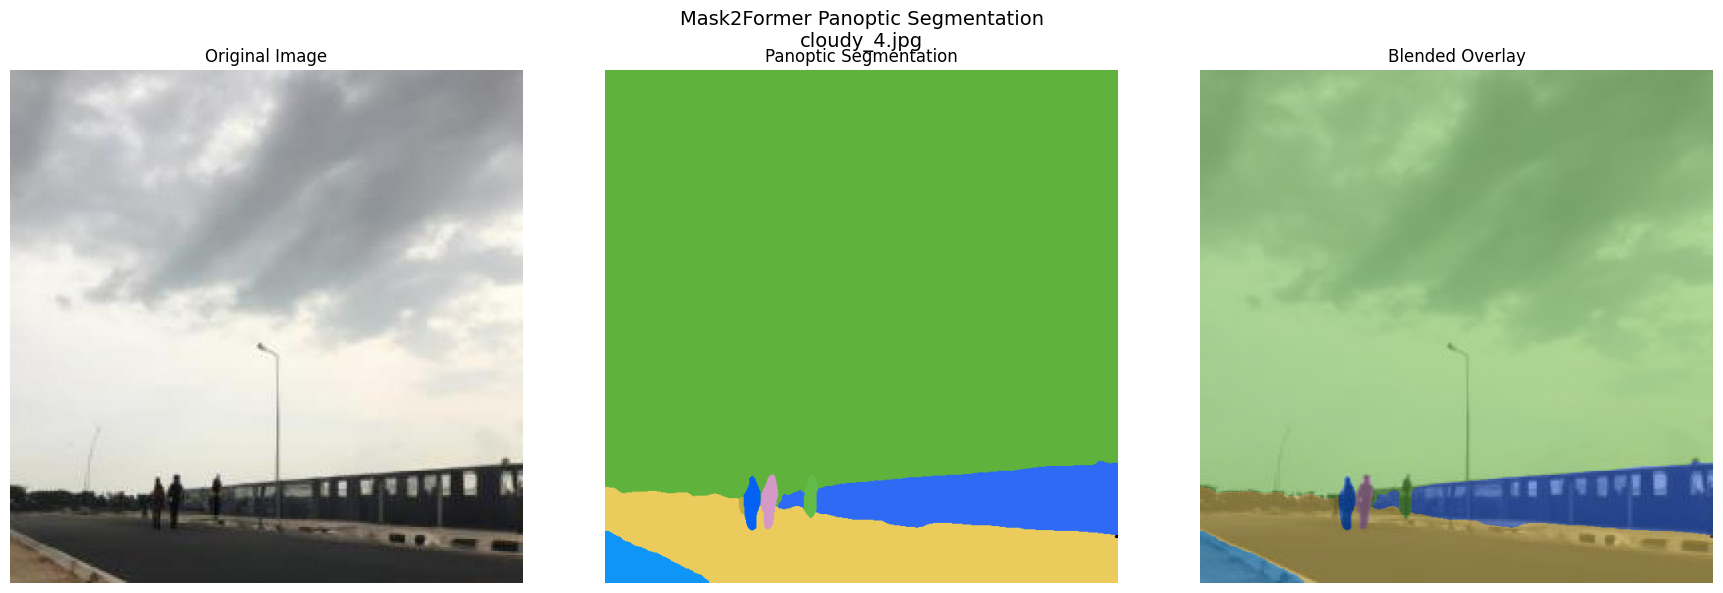

`label_ids_to_fuse` unset. No instance will be fused.


Total segments detected: 8

Processing: cloudy_5.jpg
  [Stuff] sky: 99.9%
  [Thing] person: 99.1%
  [Thing] person: 79.1%
  [Stuff] road: 99.2%
  [Thing] person: 99.7%
  [Stuff] building: 90.0%
  [Stuff] tree: 96.0%
  [Stuff] fence: 88.8%
  [Thing] person: 100.0%
  [Thing] person: 99.9%
  [Thing] person: 100.0%


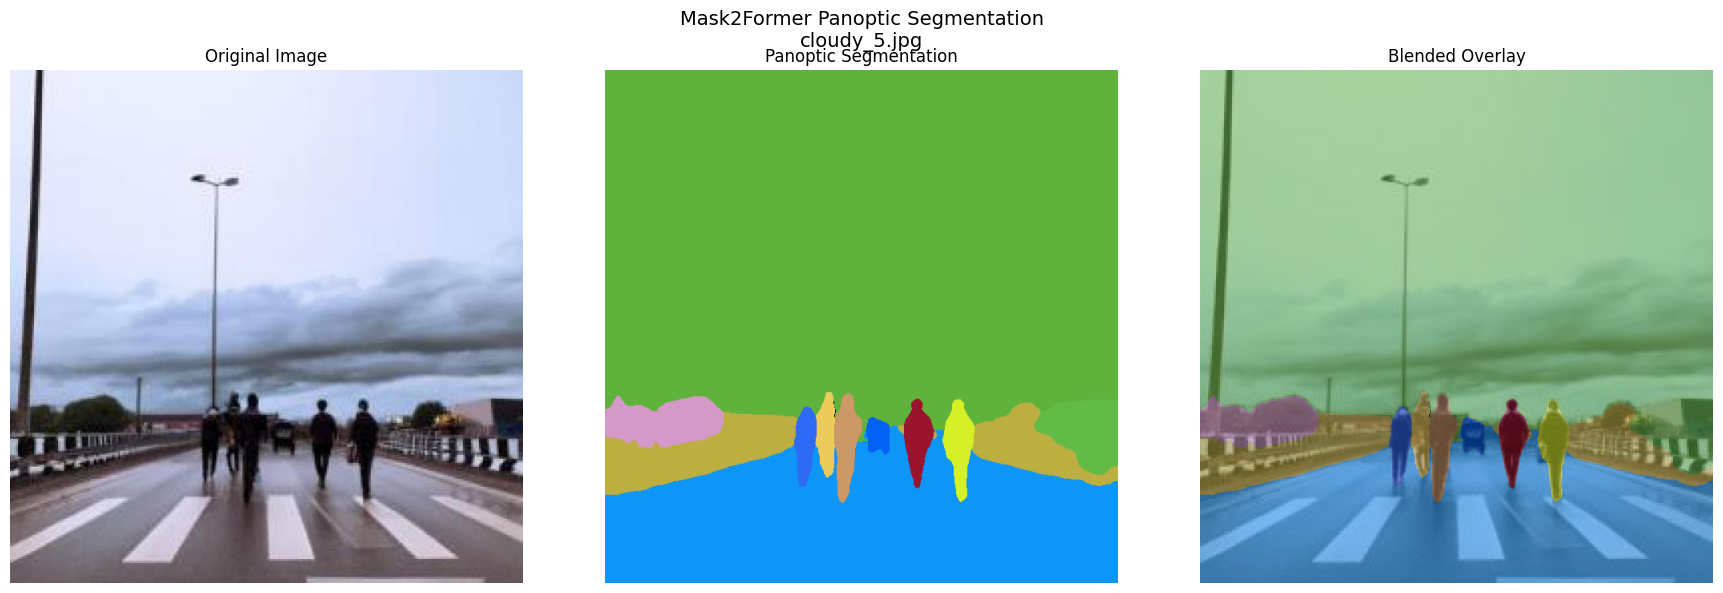

`label_ids_to_fuse` unset. No instance will be fused.


Total segments detected: 11

Processing: cloudy_6.jpg
  [Thing] handbag: 85.6%
  [Stuff] sky: 100.0%
  [Stuff] road: 95.5%
  [Thing] person: 100.0%
  [Stuff] building: 91.4%
  [Thing] person: 59.9%
  [Stuff] tree: 95.7%
  [Stuff] fence: 91.7%
  [Thing] person: 54.6%
  [Thing] person: 99.4%
  [Stuff] pavement: 77.9%


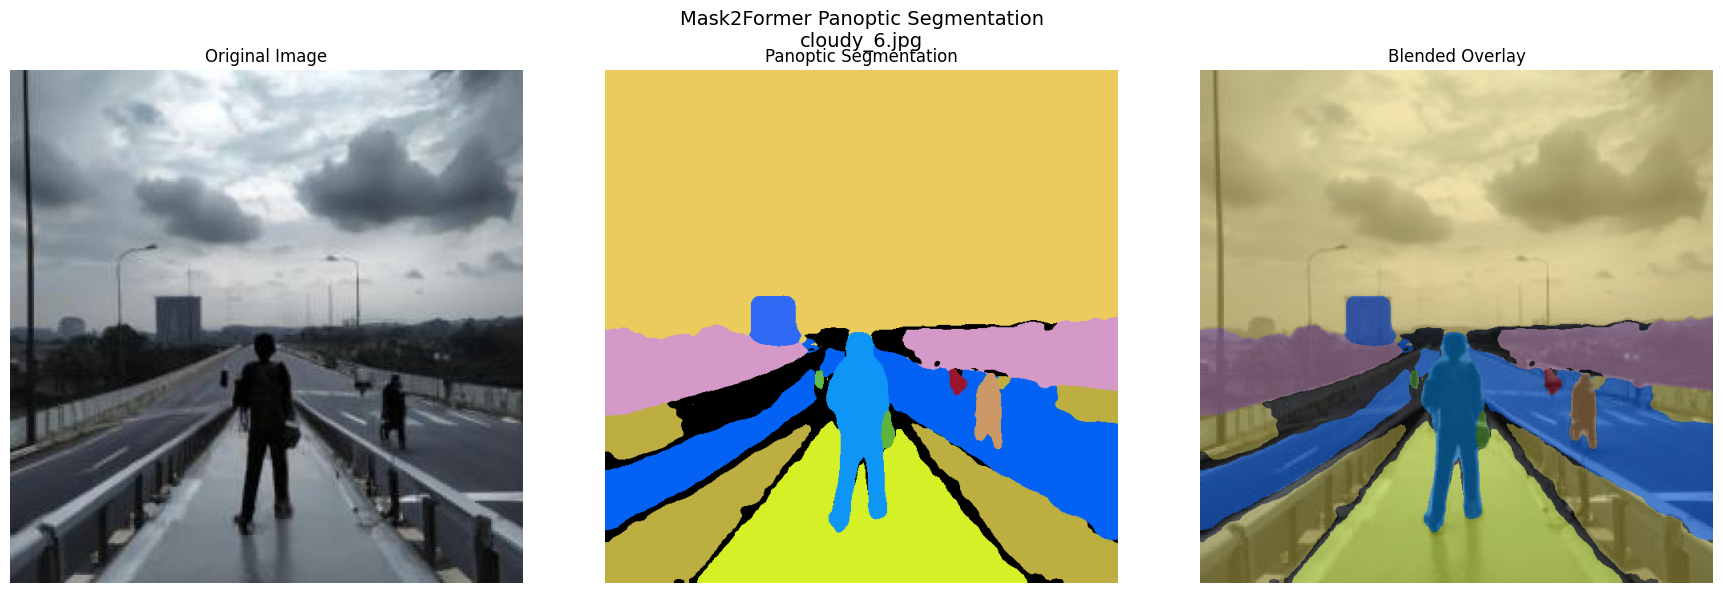

`label_ids_to_fuse` unset. No instance will be fused.


Total segments detected: 11

Processing: cloudy_7.jpg
  [Stuff] sky: 100.0%
  [Stuff] road: 97.9%
  [Thing] person: 99.8%
  [Stuff] tree: 94.8%
  [Thing] person: 99.4%
  [Stuff] fence: 77.6%
  [Thing] train: 91.5%
  [Thing] person: 100.0%


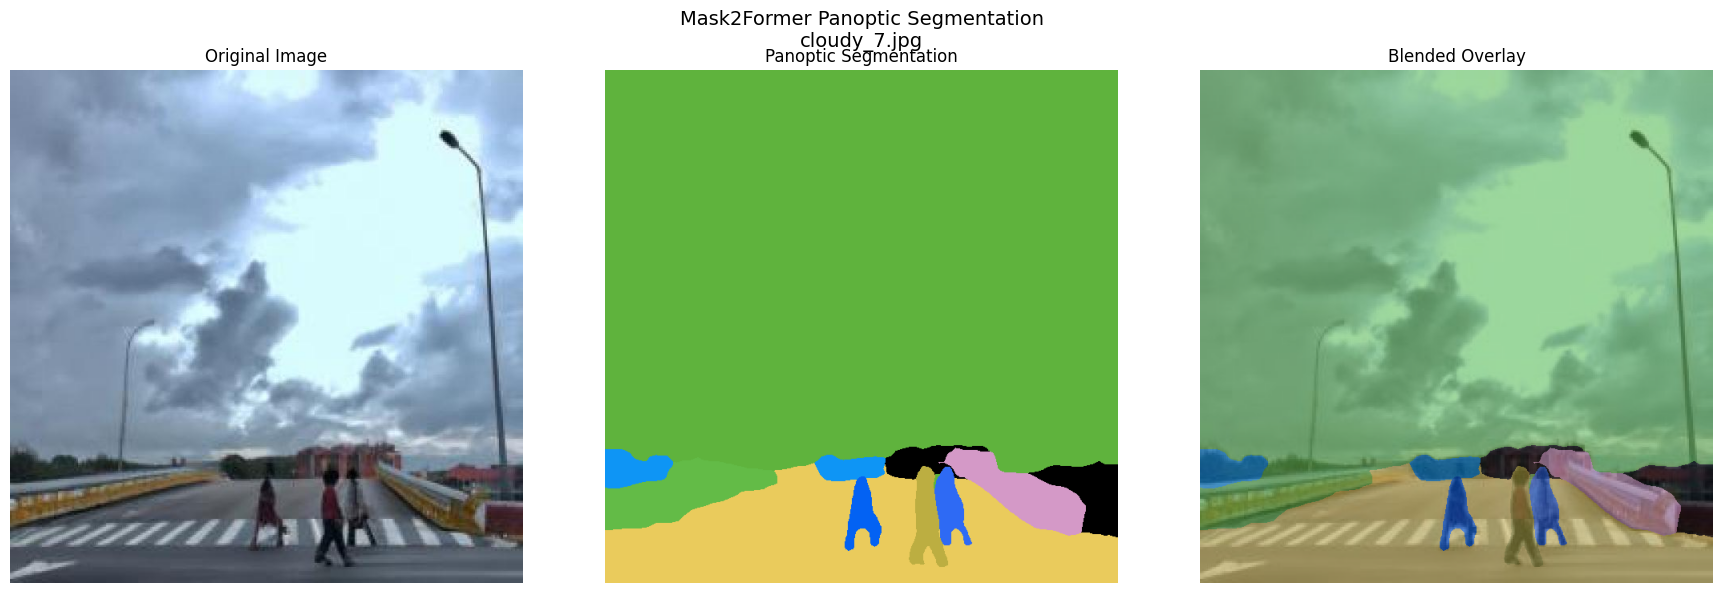

`label_ids_to_fuse` unset. No instance will be fused.


Total segments detected: 8

Processing: cloudy_8.jpg
  [Stuff] sky: 99.9%
  [Thing] person: 99.9%
  [Stuff] bridge: 93.5%
  [Thing] person: 90.6%
  [Thing] person: 94.5%
  [Thing] person: 95.7%
  [Thing] person: 99.9%
  [Thing] person: 89.6%


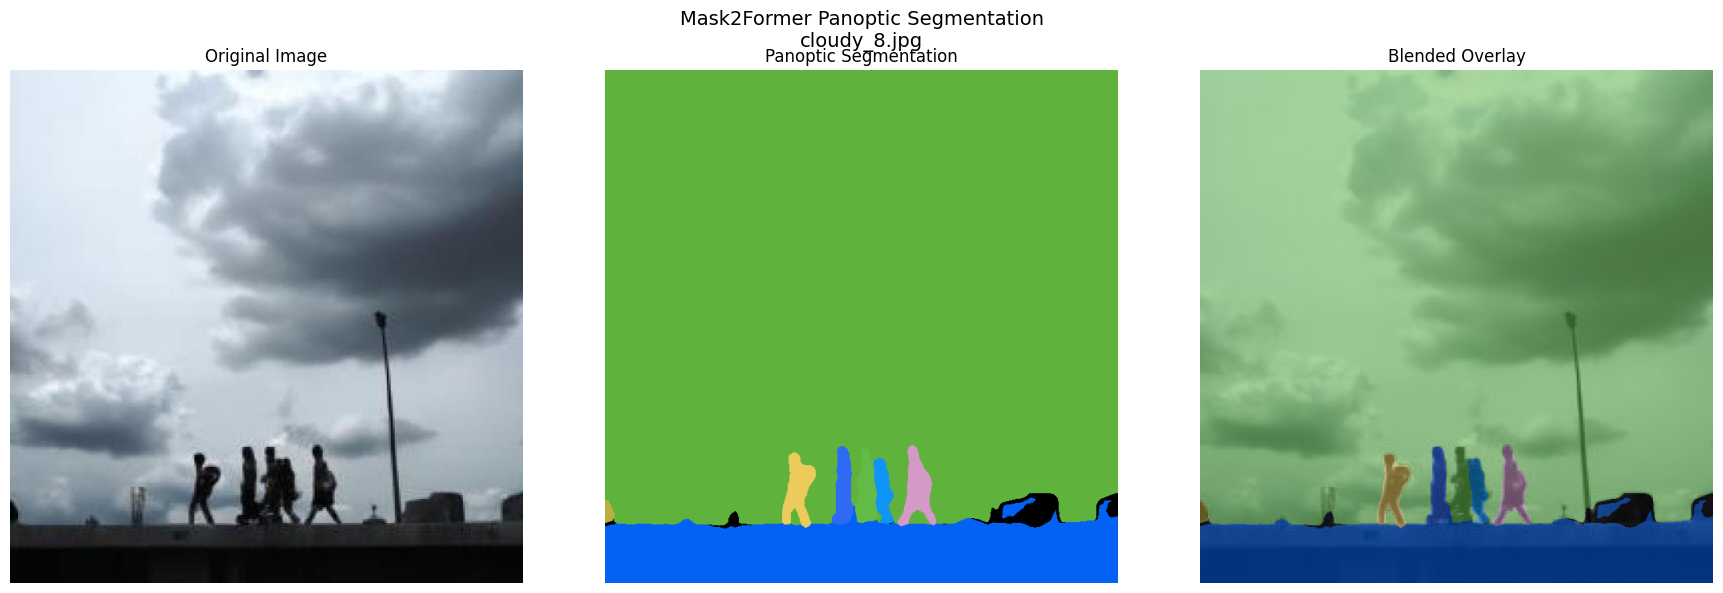

`label_ids_to_fuse` unset. No instance will be fused.


Total segments detected: 8

Processing: cloudy_9.jpg
  [Stuff] sky: 100.0%
  [Stuff] road: 98.5%
  [Thing] person: 93.3%
  [Stuff] bridge: 89.4%
  [Thing] person: 87.4%
  [Thing] person: 97.4%
  [Thing] person: 93.8%


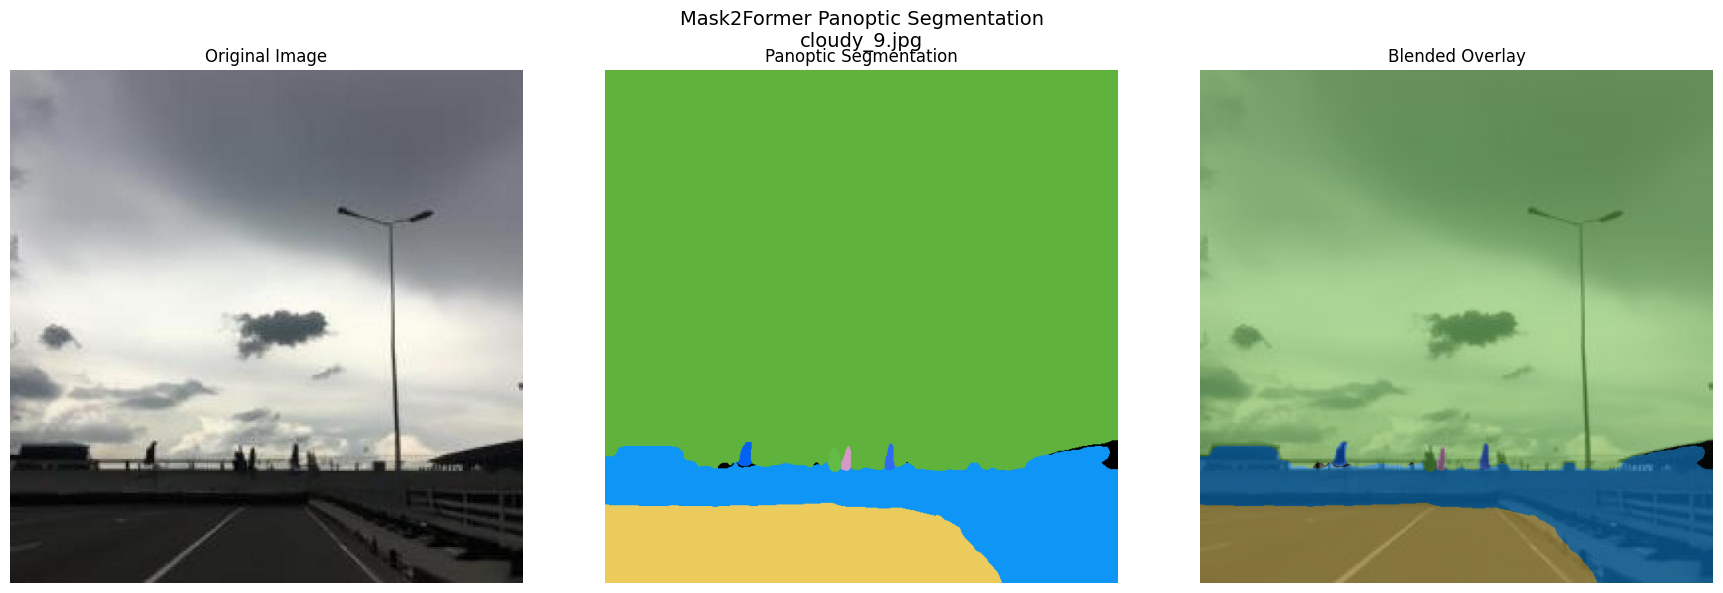

Total segments detected: 7

Mask2Former-R50 processing complete!


In [5]:
# Run Mask2Former predictions on ACDC dataset
import glob
import os

# ACDC dataset path
acdc_path = r"C:\desktop 2\project\datasets\ACDC"

# Get all images from the ACDC dataset
image_files = glob.glob(os.path.join(acdc_path, "*.jpg")) + \
              glob.glob(os.path.join(acdc_path, "*.png"))

print(f"Found {len(image_files)} images in ACDC dataset")

# COCO panoptic class names
COCO_PANOPTIC_CLASSES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck',
    'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench',
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
    'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup',
    'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
    'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse',
    'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
    'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush', 'banner', 'blanket', 'bridge', 'cardboard', 'counter', 'curtain',
    'door-stuff', 'floor-wood', 'flower', 'fruit', 'gravel', 'house', 'light',
    'mirror-stuff', 'net', 'pillow', 'platform', 'playingfield', 'railroad',
    'river', 'road', 'roof', 'sand', 'sea', 'shelf', 'snow', 'stairs', 'tent',
    'towel', 'wall-brick', 'wall-stone', 'wall-tile', 'wall-wood', 'water',
    'window-blind', 'window', 'tree', 'fence', 'ceiling', 'sky', 'cabinet',
    'table', 'floor', 'pavement', 'mountain', 'grass', 'dirt', 'paper', 'food',
    'building', 'rock', 'wall', 'rug'
]

if USE_HF:
    from PIL import Image as PILImage
    
    for img_path in image_files:
        print(f"\n{'='*60}")
        print(f"Processing: {os.path.basename(img_path)}")
        print('='*60)
        
        # Read image
        image = PILImage.open(img_path).convert("RGB")
        
        # Preprocess
        inputs = processor(images=image, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Run inference
        with torch.no_grad():
            outputs = mask2former_model(**inputs)
        
        # Post-process for panoptic segmentation
        result = processor.post_process_panoptic_segmentation(
            outputs, 
            target_sizes=[image.size[::-1]]
        )[0]
        
        # Get segmentation map and segments info
        panoptic_seg = result["segmentation"].cpu().numpy()
        segments_info = result["segments_info"]
        
        # Create visualization
        img_np = np.array(image)
        
        # Create colored segmentation overlay
        colored_seg = np.zeros_like(img_np)
        np.random.seed(42)  # For consistent colors
        colors = np.random.randint(0, 255, (256, 3), dtype=np.uint8)
        
        for seg in segments_info:
            seg_id = seg["id"]
            label_id = seg["label_id"]
            score = seg.get("score", 1.0)
            
            # Get class name
            if label_id < len(COCO_PANOPTIC_CLASSES):
                class_name = COCO_PANOPTIC_CLASSES[label_id]
            else:
                class_name = f"class_{label_id}"
            
            # Color this segment
            mask = panoptic_seg == seg_id
            colored_seg[mask] = colors[seg_id % 256]
            
            # Print detection info
            is_thing = seg.get("isthing", label_id < 80)
            seg_type = "Thing" if is_thing else "Stuff"
            print(f"  [{seg_type}] {class_name}: {score*100:.1f}%")
        
        # Blend original image with segmentation
        alpha = 0.5
        blended = (img_np * (1 - alpha) + colored_seg * alpha).astype(np.uint8)
        
        # Display results
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        axes[0].imshow(img_np)
        axes[0].set_title("Original Image")
        axes[0].axis('off')
        
        axes[1].imshow(colored_seg)
        axes[1].set_title("Panoptic Segmentation")
        axes[1].axis('off')
        
        axes[2].imshow(blended)
        axes[2].set_title("Blended Overlay")
        axes[2].axis('off')
        
        plt.suptitle(f"Mask2Former Panoptic Segmentation\n{os.path.basename(img_path)}", fontsize=14)
        plt.tight_layout()
        plt.show()
        
        print(f"Total segments detected: {len(segments_info)}")

else:
    print("\nPlease install transformers to run Mask2Former inference:")
    print("  pip install transformers")
    
    # Just display the ACDC images
    for img_path in image_files[:3]:
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(12, 8))
        plt.imshow(img_rgb)
        plt.title(f"ACDC Dataset: {os.path.basename(img_path)}")
        plt.axis('off')
        plt.show()

print("\n" + "="*60)
print("Mask2Former-R50 processing complete!")
print("="*60)